In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.examples.tutorials.mnist import input_data
mnist=input_data.read_data_sets('MNIST_data',one_hot=True)

/home/bot/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters


Extracting MNIST_data/train-images-idx3-ubyte.gz
Extracting MNIST_data/train-labels-idx1-ubyte.gz
Extracting MNIST_data/t10k-images-idx3-ubyte.gz
Extracting MNIST_data/t10k-labels-idx1-ubyte.gz


In [2]:
train_data = mnist.train.images[:5000]
train_label = mnist.train.labels[:5000]

In [3]:
train_data.shape

(5000, 784)

In [45]:
EPOCHS = 20
BATCH_SIZE = 100
LEARNING_RATE = 0.001

In [46]:
def get_batch(data,label,Epochs,Batch_size):
    for epoch in range(Epochs):
        index_list = list(range(len(data)))
        chosen_index = np.random.permutation(index_list)[:Batch_size]
        batch_data = data[chosen_index,:]
        batch_label = label[chosen_index,:]
        yield batch_data,batch_label

In [47]:
def network(xs):
    with tf.variable_scope('conv_layers',reuse=tf.AUTO_REUSE):
        image = tf.reshape(xs,shape=[-1,28,28,1])
        conv1 = tf.layers.conv2d(inputs=image,filters=16,kernel_size=5,strides=1,padding='same',activation=tf.nn.relu)
        pool1 = tf.layers.max_pooling2d(inputs=conv1,pool_size=2,strides=2)   #14*14*16
        conv2 = tf.layers.conv2d(inputs=pool1,filters=32,kernel_size=5,strides=1,padding='same',activation=tf.nn.relu)
        pool2 = tf.layers.max_pooling2d(inputs=conv2,pool_size=2,strides=2)    #7*7*32
        flat = tf.reshape(pool2,[-1,7*7*32])
        feature = tf.layers.dense(flat,2,name='feature')
        output = tf.layers.dense(feature,10,name='output')
    return feature,output

In [48]:
def get_placeholder():
    xs = tf.placeholder(tf.float32,[None,28*28])
    ys = tf.placeholder(tf.float32,[None,10])
    return xs,ys

In [53]:
tf.reset_default_graph()
train_graph = tf.Graph()
with train_graph.as_default():
    xs,ys = get_placeholder()    
    feature,output = network(xs)
    with tf.name_scope('loss'):
        loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=ys,logits=output))
    global_step = tf.Variable(0,name='gloabl_step',trainable=False)
    with tf.name_scope('train_op'):
        learning_rate = tf.train.exponential_decay(LEANRING_RATE, global_step, 5000, 0.5, staircase=True)
        optimizer = tf.train.AdamOptimizer(LEARNING_RATE)
        gradients = optimizer.compute_gradients(loss)
        train_op = optimizer.apply_gradients(gradients,global_step=global_step)

In [55]:
import os
import time
with tf.Session(graph=train_graph) as sess:
    init = tf.global_variables_initializer()
    loss_summary = tf.summary.scalar('loss',loss)
    train_summary_op = tf.summary.merge_all()
    sess.run(init)
    timestamp = str(int(time.time()))
    out_dir = os.path.abspath(os.path.join(os.path.curdir, 'mnist',timestamp))
    print('write to {}\n--------'.format(out_dir))
    train_summary_writer = tf.summary.FileWriter(out_dir, sess.graph)
    for epoch in range(EPOCHS):
        for i in range(mnist.train.num_examples//BATCH_SIZE):
            train_data,train_label = mnist.train.next_batch(BATCH_SIZE)
            summary,step,_ = sess.run([train_summary_op,global_step,train_op],feed_dict={xs:train_data,ys:train_label})
            train_summary_writer.add_summary(summary, step)
    train_data = mnist.train.images[:5000]
    train_label = mnist.train.labels[:5000]
    feature = sess.run(feature,feed_dict={xs:train_data,ys:train_label})

write to /home/bot/Desktop/cmq/test/mnist/1523445638
--------


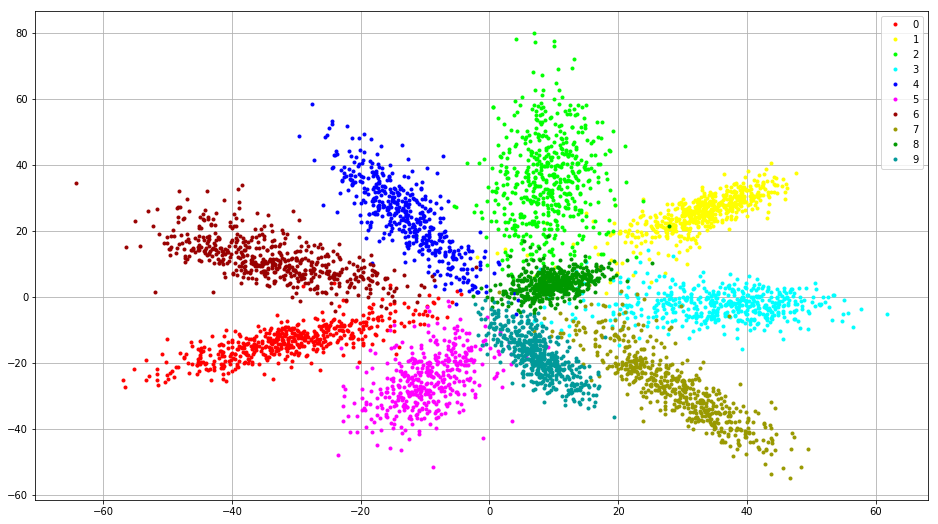

In [56]:
a = np.argmax(train_label,axis=1)
f = plt.figure(figsize=(16,9))
c = ['#ff0000', '#ffff00', '#00ff00', '#00ffff', '#0000ff', 
     '#ff00ff', '#990000', '#999900', '#009900', '#009999']
for i in range(10):
    plt.plot(feature[a==i,0].flatten(), feature[a==i,1].flatten(), '.', c=c[i])
plt.legend(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
plt.grid()
plt.show()

In [34]:
labels = mnist.test.labels[:10000]
labels.shape

(10000, 10)

In [ ]:
for i in range(10):
    feature

In [35]:
feature

array([[-11.092053  ,   0.22526959],
       [ -3.4213214 , -11.071721  ],
       [ -4.649982  ,  -2.4917817 ],
       ...,
       [ -2.5667827 ,  -0.52207875],
       [ -2.503256  ,   2.6243694 ],
       [ 18.631863  ,  -2.4717479 ]], dtype=float32)

In [37]:
feature[labels==1,0]

IndexError: too many indices for array